# Stim Flip Simulator

In [1]:
import stim
import stim
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
def set_global_seeds(seed=12345):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## Toy Example Data Generation

### X-Error

In [3]:
import stim

# 1. Initialize FlipSimulator
# We use batch_size=1 for a single shot.
# Setting disable_stabilizer_randomization=True is critical: it prevents the 
# simulator from injecting random flips during measurements or initialization, 
# strictly isolating the deliberate errors we want to track.
sim = stim.FlipSimulator(batch_size=2, disable_stabilizer_randomization=True)

# 2. Break the circuit down into chunks to track the error step-by-step
initial_circuit = stim.Circuit("""
    # Create a Bell pair between Q0 and Q1
    H 0
    CX 0 1
""")

error_circuit = stim.Circuit("""
    # Deliberately inject an X error on Q1 with 100% probability
    X_ERROR(1.0) 1
""")

propagation_circuit = stim.Circuit("""
    # Apply a CNOT from Q1 (control) to Q2 (target)
    CX 1 2
""")

# --- Step 1: Clean State ---
print("--- After Initial Gate Setup ---")
sim.do(initial_circuit)
print("Pauli string:", sim.peek_pauli_flips()[0]) 
# Expected: +___ (No errors on the qubits)


# --- Step 2: Injecting the Error ---
print("\n--- After Injecting X_ERROR on Q1 ---")
sim.do(error_circuit)

# Peek at the current frame for shot 0
paulis = sim.peek_pauli_flips()[0]
print("Pauli string:", paulis) # Expected: +_X_ (Error is on Q1)

# To programmatically find exactly WHERE the error is:
xs, zs = paulis.to_numpy(bit_packed=False)
x_error_locations = [q for q, has_x in enumerate(xs) if has_x]
print(f"-> Qubits suffering an X flip right now: {x_error_locations}")


# --- Step 3: Error Propagation ---
print("\n--- After CNOT from Q1 to Q2 ---")
sim.do(propagation_circuit)

paulis = sim.peek_pauli_flips()[0]
print("Pauli string:", paulis) # Expected: +_XX 

# Check where the errors are now
xs, zs = paulis.to_numpy(bit_packed=False)
x_error_locations = [q for q, has_x in enumerate(xs) if has_x]
print(f"-> Qubits suffering an X flip right now: {x_error_locations}")

--- After Initial Gate Setup ---
Pauli string: +__

--- After Injecting X_ERROR on Q1 ---
Pauli string: +_X
-> Qubits suffering an X flip right now: [1]

--- After CNOT from Q1 to Q2 ---
Pauli string: +_XX
-> Qubits suffering an X flip right now: [1, 2]


In [4]:
paulis.to_numpy(bit_packed=False)

(array([False,  True,  True]), array([False, False, False]))

### Z-Error

In [5]:
import stim

# Initialize FlipSimulator
sim = stim.FlipSimulator(batch_size=1, disable_stabilizer_randomization=True)

# --- Define the Circuit Components ---
# Qubits 0 and 1 are Data. Qubit 2 is the Auxiliary (Measure) qubit.

# A standard clean XX measurement layer
clean_xx_layer = stim.Circuit("""
    R 2         # Reset Aux qubit
    H 0 1       # Rotate Data to X basis
    CX 0 2      # Entangle Q0 to Aux
    CX 1 2      # Entangle Q1 to Aux
    H 0 1       # Rotate Data back to Z basis
    M 2         # Measure Aux
""")

# We will break down Layer 2 to watch the error propagate gate-by-gate
layer2_step1 = stim.Circuit("R 2 \n H 0 1")
layer2_step2 = stim.Circuit("CX 0 2")
layer2_step3 = stim.Circuit("CX 1 2")
layer2_step4 = stim.Circuit("H 0 1 \n M 2")

# --- Execution & Tracking ---

print("=== LAYER 1: Clean State ===")
sim.do(clean_xx_layer)
print("Pauli string after Layer 1: ", sim.peek_pauli_flips()[0])
# Expected: +___ (No errors)

print("\n=== INJECTING ERROR ===")
# Inject a Z error on Q0. 
sim.do(stim.Circuit("Z_ERROR(1.0) 0"))
print("Pauli string after Injection:", sim.peek_pauli_flips()[0])
# Expected: +Z__ (Z error sitting on Q0)

print("\n=== LAYER 2: Tracking the Flip Propagation ===")
sim.do(layer2_step1)
print("After R 2 and H 0 1:        ", sim.peek_pauli_flips()[0])
# The Z error on Q0 passes through the Hadamard (H) and becomes an X error!
# Expected: +X__

sim.do(layer2_step2)
print("After CX 0 2:               ", sim.peek_pauli_flips()[0])
# The X error on Q0 (control) copies to Q2 (target) via the CNOT.
# Expected: +X_X

sim.do(layer2_step3)
print("After CX 1 2:               ", sim.peek_pauli_flips()[0])
# Q1 has no errors, so nothing changes here.
# Expected: +X_X

sim.do(layer2_step4)
print("After H 0 1 and M 2:        ", sim.peek_pauli_flips()[0])
# The X on Q0 turns back into a Z. 
# The X on Q2 flips the measurement outcome!
# Expected: +Z_X

print("\n=== LAYER 3: Lingering Errors ===")
# Run the third layer normally. 
sim.do(clean_xx_layer)
print("Pauli string after Layer 3: ", sim.peek_pauli_flips()[0])
# Expected: +Z_X 
# (The Z error remains on Q0, and it flips the Q2 measurement AGAIN in Layer 3)

# To check if the measurement itself was flipped:
measure_flips = sim.get_measurement_flips()[0]
print(f"\nMeasurement Flips (Layer 1, Layer 2, Layer 3): {measure_flips}")
# Expected: [False, True, True]

=== LAYER 1: Clean State ===
Pauli string after Layer 1:  +___

=== INJECTING ERROR ===
Pauli string after Injection: +Z__

=== LAYER 2: Tracking the Flip Propagation ===
After R 2 and H 0 1:         +X__
After CX 0 2:                +X_X
After CX 1 2:                +X_X
After H 0 1 and M 2:         +Z_X

=== LAYER 3: Lingering Errors ===
Pauli string after Layer 3:  +Z_X

Measurement Flips (Layer 1, Layer 2, Layer 3): [False]


### XZ-Errors

In [6]:
import stim

# 1. Initialize FlipSimulator
sim = stim.FlipSimulator(batch_size=1, disable_stabilizer_randomization=True)

# 2. Define the Alternating Measurement Circuits
# Q0, Q1 = Data Qubits | Q2 = Auxiliary Qubit

xx_layer = stim.Circuit("""
    R 2         # Reset Aux
    H 0 1       # Rotate Data to X basis
    CX 0 2      # Parity check
    CX 1 2
    H 0 1       # Rotate Data back to Z basis
    M 2         # Measure Aux
""")

zz_layer = stim.Circuit("""
    R 2         # Reset Aux
    CX 0 2      # Parity check
    CX 1 2
    M 2         # Measure Aux
""")

# --- LAYER 1: Clean XX Measurement ---
print("--- Layer 1: XX Measurement (Clean State) ---")
sim.do(xx_layer)
print("Pauli frame:      ", sim.peek_pauli_flips()[0])


# --- INJECTING DUAL ERRORS ---
print("\n--- Injecting X on Q0 and Z on Q1 ---")
sim.do(stim.Circuit("""
    X_ERROR(1.0) 0
    Z_ERROR(1.0) 1
"""))
print("Pauli frame:      ", sim.peek_pauli_flips()[0]) # Expected: +XZ_


# --- LAYER 2: ZZ Measurement ---
print("\n--- Layer 2: ZZ Measurement ---")
sim.do(zz_layer)
print("Pauli frame:      ", sim.peek_pauli_flips()[0]) 
# The X error on Q0 copied to Q2, triggering a measurement flip!


# --- LAYER 3: XX Measurement ---
print("\n--- Layer 3: XX Measurement ---")
sim.do(xx_layer)
print("Pauli frame:      ", sim.peek_pauli_flips()[0])
# Hadamards turn Z on Q1 into an X, copying it to Q2 and flipping this measurement!


# --- LAYER 4: ZZ Measurement ---
print("\n--- Layer 4: ZZ Measurement ---")
sim.do(zz_layer)
print("Pauli frame:      ", sim.peek_pauli_flips()[0])
# The X on Q0 triggers the ZZ measurement again!


# --- SUMMARY OF MEASUREMENT FLIPS ---
measurement_results = sim.get_measurement_flips()[0]
print("\n" + "="*45)
print("Measurement Flips across [Layer 1, Layer 2, Layer 3, Layer 4]:")
print(measurement_results) # Expected: [False, True, True, True]

--- Layer 1: XX Measurement (Clean State) ---
Pauli frame:       +___

--- Injecting X on Q0 and Z on Q1 ---
Pauli frame:       +XZ_

--- Layer 2: ZZ Measurement ---
Pauli frame:       +XZX

--- Layer 3: XX Measurement ---
Pauli frame:       +XZX

--- Layer 4: ZZ Measurement ---
Pauli frame:       +XZX

Measurement Flips across [Layer 1, Layer 2, Layer 3, Layer 4]:
[False]


### Circuit Level Noise Model

In [7]:
import stim

# Define our error probability (e.g., 2% chance of error at any point)
p = 0.02

# --- 1. Define Noisy Layers ---
# Qubits 0,1 (Data) and 2 (Aux)
# Qubits 3,4 (Data) and 5 (Aux)

noisy_xx_layer = stim.Circuit(f"""
    # Initialize with X error
    R 2 5
    X_ERROR({p}) 2 5
    
    # Basis change with 1-qubit depolarizing noise
    H 0 1 3 4
    DEPOLARIZE1({p}) 0 1 3 4
    
    # First CNOT step with 2-qubit depolarizing noise
    CX 0 2 3 5
    DEPOLARIZE2({p}) 0 2 3 5
    
    # Second CNOT step with 2-qubit depolarizing noise
    CX 1 2 4 5
    DEPOLARIZE2({p}) 1 2 4 5
    
    # Revert basis change with 1-qubit depolarizing noise
    H 0 1 3 4
    DEPOLARIZE1({p}) 0 1 3 4
    
    # Measurement is preceded by an X error
    X_ERROR({p}) 2 5
    M 2 5
""")

noisy_zz_layer = stim.Circuit(f"""
    # Initialize with X error
    R 2 5
    X_ERROR({p}) 2 5
    
    # CNOTs with 2-qubit depolarizing noise
    CX 0 2 3 5
    DEPOLARIZE2({p}) 0 2 3 5
    
    CX 1 2 4 5
    DEPOLARIZE2({p}) 1 2 4 5
    
    # Measurement is preceded by an X error
    X_ERROR({p}) 2 5
    M 2 5
""")

# --- 2. Build the Full Schedule ---
full_schedule = (
    noisy_xx_layer + 
    noisy_xx_layer + 
    noisy_zz_layer + 
    noisy_zz_layer + 
    noisy_xx_layer
)

# --- 3. Execute and Track with FlipSimulator ---
# Notice we DO NOT disable randomization here. We want Stim to roll the 
# dice based on our 'p' values and naturally inject the circuit-level noise.
sim = stim.FlipSimulator(batch_size=1)

print("=== Simulating 5 Layers of Circuit-Level Noise ===\n")

layers = [
    ("Layer 1 (XX)", noisy_xx_layer),
    ("Layer 2 (XX)", noisy_xx_layer),
    ("Layer 3 (ZZ)", noisy_zz_layer),
    ("Layer 4 (ZZ)", noisy_zz_layer),
    ("Layer 5 (XX)", noisy_xx_layer),
]

for name, layer_circuit in layers:
    sim.do(layer_circuit)
    
    # Peek at what errors the noise model randomly injected and propagated
    current_paulis = sim.peek_pauli_flips()[0]
    
    print(f"--- {name} ---")
    print(f"Current Pauli Frame: {current_paulis}")
    
    # Find exact locations of any X or Z errors on the data qubits (0, 1, 3, 4)
    xs, zs = current_paulis.to_numpy(bit_packed=False)
    x_locs = [q for q, has_x in enumerate(xs) if has_x and q in [0, 1, 3, 4]]
    z_locs = [q for q, has_z in enumerate(zs) if has_z and q in [0, 1, 3, 4]]
    
    if x_locs or z_locs:
        print(f"-> Active Data Errors: X on {x_locs}, Z on {z_locs}")
    else:
        print("-> Active Data Errors: None (Clean)")
    print()

# --- 4. Review Measurement Flips ---
# Because of the noise, some measurements will be flipped!
measurement_flips = sim.get_measurement_flips()
print("=== Final Measurement Flip Record ===")
print("Note: 2 measurements per layer (Block 1 Aux, Block 2 Aux)")

# Group the 10 measurements into the 5 layers
for i in range(5):
    m1 = measurement_flips[i*2]
    m2 = measurement_flips[i*2 + 1]
    # print(f"Layer {i+1}: Aux Q2 Flipped? {m1:<5} | Aux Q5 Flipped? {m2}")
    print(m1, " - ", m2)

=== Simulating 5 Layers of Circuit-Level Noise ===

--- Layer 1 (XX) ---
Current Pauli Frame: +XXZZZZ
-> Active Data Errors: X on [0, 1], Z on [3, 4]

--- Layer 2 (XX) ---
Current Pauli Frame: +XX_ZZ_
-> Active Data Errors: X on [0, 1], Z on [3, 4]

--- Layer 3 (ZZ) ---
Current Pauli Frame: +XXZ___
-> Active Data Errors: X on [0, 1], Z on []

--- Layer 4 (ZZ) ---
Current Pauli Frame: +YY____
-> Active Data Errors: X on [0, 1], Z on [0, 1]

--- Layer 5 (XX) ---
Current Pauli Frame: +YY____
-> Active Data Errors: X on [0, 1], Z on [0, 1]

=== Final Measurement Flip Record ===
Note: 2 measurements per layer (Block 1 Aux, Block 2 Aux)
[False]  -  [False]
[False]  -  [False]
[False]  -  [False]
[False]  -  [False]
[False]  -  [False]


# NN Decoder

## Toy Example

### Circuit Generation

In [8]:
# # ==========================================
# # 1. DEFINE THE 12-QUBIT CIRCUIT
# # Data Qubits: 0 to 7
# # Aux Qubits: 8 to 11
# # ==========================================
# def build_circuit(p=0.01):
#     data_qubits = "0 1 2 3 4 5 6 7"
#     aux_qubits = "8 9 10 11"
    
#     # Helper for CNOTs connecting Data to Aux
#     cnot_pairs_1 = "0 8 2 9 4 10 6 11"
#     cnot_pairs_2 = "1 8 3 9 5 10 7 11"

#     cnot_pairs_1_zz = "8 0 9 2 10 4 11 6"
#     cnot_pairs_2_zz = "8 1 9 3 10 5 11 7"

#     # XX Layer (Detects Z errors)
#     xx_layer = f"""
#         R {aux_qubits}
#         H {aux_qubits}
#         DEPOLARIZE1({p}) {data_qubits}
#         CX {cnot_pairs_1}
#         DEPOLARIZE2({p}) {cnot_pairs_1}
#         CX {cnot_pairs_2}
#         DEPOLARIZE2({p}) {cnot_pairs_2}
#         H {aux_qubits}
#         DEPOLARIZE1({p}) {aux_qubits}
#         X_ERROR({p}) {aux_qubits}
#         M {aux_qubits}
#     """
    
#     # ZZ Layer (Detects X errors)
#     zz_layer = f"""
#         R {aux_qubits}
#         CX {cnot_pairs_1_zz}
#         DEPOLARIZE2({p}) {cnot_pairs_1_zz}
#         CX {cnot_pairs_2_zz}
#         DEPOLARIZE2({p}) {cnot_pairs_2_zz}
#         X_ERROR({p}) {aux_qubits}
#         M {aux_qubits}
#     """
    
#     # Schedule: XX -> ZZ -> XX
#     return stim.Circuit(xx_layer + zz_layer + xx_layer)

In [9]:
import stim
import numpy as np
import torch

def build_circuit(p=0.01):
    # Data Qubits: 0, 1, 3, 4, 5, 6, 7 are FROZEN
    # Data Qubit: 2 is the INFORMATION QUBIT
    data_qubits = "0 1 2 3 4 5 6 7"
    aux_qubits = "8 9 10 11"
    
    cnot_pairs_1 = "0 8 2 9 4 10 6 11"
    cnot_pairs_2 = "1 8 3 9 5 10 7 11"
    cnot_pairs_1_zz = "8 0 9 2 10 4 11 6"
    cnot_pairs_2_zz = "8 1 9 3 10 5 11 7"

    # Step 1: Initialize Frozen State
    # Reset all data qubits to |0> state
    prep_stage = f"""
        R {data_qubits}
        X_ERROR({p}) {data_qubits}
        R {aux_qubits}
        X_ERROR({p}) {aux_qubits}
    """

    # XX Measurement Layer
    xx_layer = f"""
        H {aux_qubits}
        DEPOLARIZE1({p}) {aux_qubits}
        CX {cnot_pairs_1}
        DEPOLARIZE2({p}) {cnot_pairs_1}
        CX {cnot_pairs_2}
        DEPOLARIZE2({p}) {cnot_pairs_2}
        H {aux_qubits}
        DEPOLARIZE1({p}) {aux_qubits}
        X_ERROR({p}) {aux_qubits}
        M {aux_qubits}
    """
    
    # ZZ Measurement Layer
    zz_layer = f"""
        R {aux_qubits}
        CX {cnot_pairs_1_zz}
        DEPOLARIZE2({p}) {cnot_pairs_1_zz}
        CX {cnot_pairs_2_zz}
        DEPOLARIZE2({p}) {cnot_pairs_2_zz}
        X_ERROR({p}) {aux_qubits}
        M {aux_qubits}
    """
    
    # Schedule: Init Frozen -> XX -> ZZ -> XX
    return stim.Circuit(prep_stage + xx_layer + zz_layer + xx_layer)

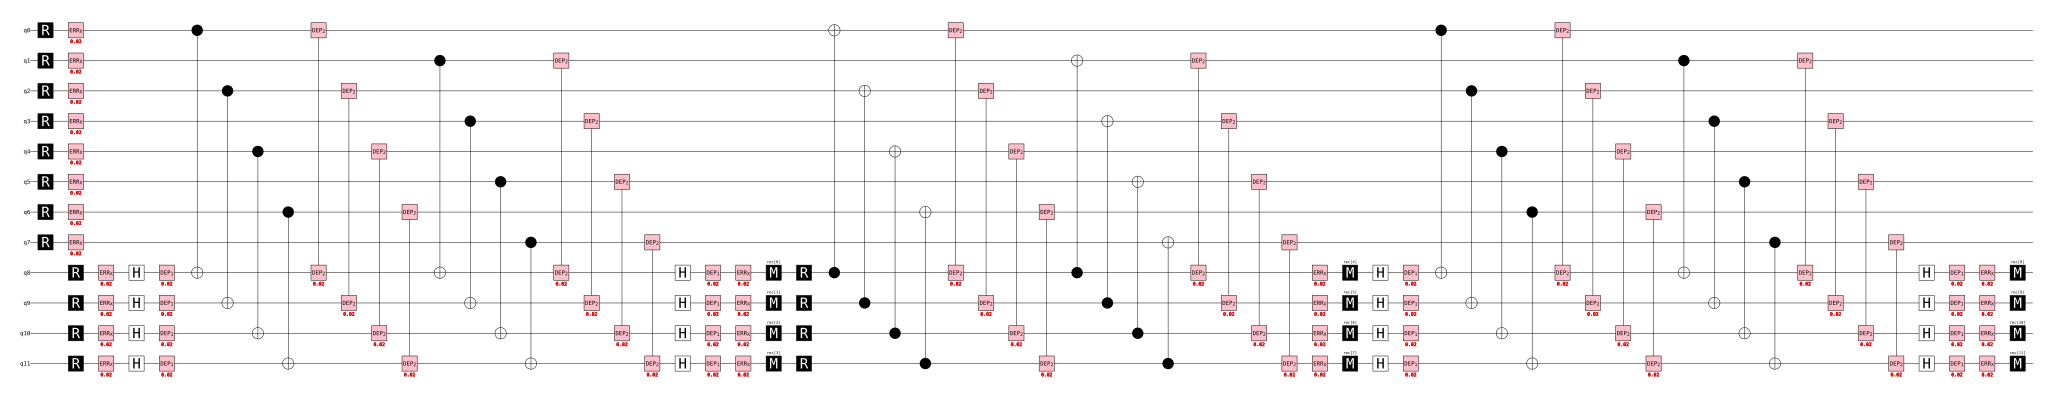

In [10]:
circuit = build_circuit(p)
circuit.diagram("timeline-svg")

### Data Generation

In [11]:
# # ==========================================
# # 2. GENERATE TRAINING DATA USING FLIP SIMULATOR
# # ==========================================
# def generate_dataset(num_samples, p=0.01):
#     circuit = build_circuit(p)
    
#     # We can batch the simulator to generate data instantly
#     sim = stim.FlipSimulator(batch_size=num_samples)
#     sim.do(circuit)
    
#     # INPUT (X): The measurement outcomes (syndromes)
#     # 3 layers * 4 aux qubits = 12 measurements per shot
#     measurements = sim.get_measurement_flips()
#     X = np.array(measurements, dtype=np.float32)
#     # print("X:", X)

#     if len(X.shape) == 2 and X.shape[0] != num_samples and X.shape[1] == num_samples:
#         X = X.T  # This flips it to (50000, 12)
    
#     # LABEL (Y): The exact final errors on the 8 Data Qubits
#     # We want to predict if an X or Z error is present on Q0-Q7
#     final_paulis = sim.peek_pauli_flips()
    
#     Y_list = []
#     for shot in range(num_samples):
#         xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
        
#         # Extract only the data qubits (0 to 7)
#         x_data_errors = xs[0:8]
#         z_data_errors = zs[0:8]
        
#         # Concatenate into a single 16-bit array: [X0..X7, Z0..Z7]
#         y_row = np.concatenate([x_data_errors, z_data_errors])
#         Y_list.append(y_row)
        
#     Y = np.array(Y_list, dtype=np.float32)
    
#     return torch.tensor(X), torch.tensor(Y)



In [12]:
# def generate_dataset(num_samples, p=0.01):
#     circuit = build_circuit(p)
#     sim = stim.FlipSimulator(batch_size=num_samples)
#     sim.do(circuit)
    
#     # Extract syndromes X (shape: num_samples, 12)
#     measurements = sim.get_measurement_flips()
#     X = np.array(measurements, dtype=np.float32)
#     if len(X.shape) == 2 and X.shape[0] != num_samples:
#         X = X.T
        
#     # Extract ground truth errors Y (shape: num_samples, 16)
#     final_paulis = sim.peek_pauli_flips()
#     Y_list = []
#     for shot in range(num_samples):
#         xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
#         # Tracks errors on ALL data qubits (0 to 7)
#         # Note: Index 2 of y_row is X-error on Info Qubit 2
#         # Index 10 of y_row is Z-error on Info Qubit 2
#         y_row = np.concatenate([xs[0:8], zs[0:8]])
#         Y_list.append(y_row)
        
#     Y = np.array(Y_list, dtype=np.float32)
    
#     return torch.tensor(X), torch.tensor(Y)

In [13]:
def generate_dataset(num_samples, p=0.03):
    # Over-generate samples to ensure we collect enough non-trivial errored shots
    raw_samples = int(num_samples * 4)
    
    circuit = build_circuit(p)
    sim = stim.FlipSimulator(batch_size=raw_samples)
    sim.do(circuit)
    
    measurements = sim.get_measurement_flips()
    X = np.array(measurements, dtype=np.float32)
    if len(X.shape) == 2 and X.shape[0] != raw_samples:
        X = X.T
        
    final_paulis = sim.peek_pauli_flips()
    Y_list = []
    for shot in range(raw_samples):
        xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
        # We extract ONLY the X and Z error status of Information Qubit 2 (Index 2)
        q2_x_error = float(xs[2])
        q2_z_error = float(zs[2])
        Y_list.append([q2_x_error, q2_z_error])
        
    Y = np.array(Y_list, dtype=np.float32)
    
    # Keep ONLY non-trivial errored shots (syndrome sum > 0)
    error_detected_mask = (X.sum(axis=1) > 0)
    
    X_filtered = X[error_detected_mask][:num_samples]
    Y_filtered = Y[error_detected_mask][:num_samples]
    
    print(f"Collected {len(X_filtered)} non-trivial errored shots (Syndrome > 0).")
    return torch.tensor(X_filtered), torch.tensor(Y_filtered)

In [14]:
X_train, Y_train = generate_dataset(10, p=0.005) 

Collected 5 non-trivial errored shots (Syndrome > 0).


In [15]:
X_train, Y_train

(tensor([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
         [1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 tensor([[0., 1.],
         [0., 0.],
         [0., 0.],
         [0., 1.],
         [0., 1.]]))

#### Visualizing one shot

In [16]:
# import stim
# import numpy as np
# import torch

# # (Insert your build_circuit function here)

# def generate_dataset(num_samples, p=0.01):
#     circuit = build_circuit(p)
#     sim = stim.FlipSimulator(batch_size=num_samples)
#     sim.do(circuit)
    
#     measurements = sim.get_measurement_flips()
#     X = np.array(measurements, dtype=np.float32)
    
#     final_paulis = sim.peek_pauli_flips()
#     Y_list = []
#     for shot in range(num_samples):
#         xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
#         y_row = np.concatenate([xs[0:8], zs[0:8]])
#         Y_list.append(y_row)
        
#     Y = np.array(Y_list, dtype=np.float32)
#     return torch.tensor(X), torch.tensor(Y)

# # Generate just 1 sample with a high error rate (5%)
# X_data, Y_data = generate_dataset(1, p=0.05)

# # Convert to integers for cleaner printing
# x_shot = X_data[0].int().numpy()
# y_shot = Y_data[0].int().numpy()

# print("=== THE INPUT (What the Neural Network sees) ===")
# print(f"Layer 1 (XX): {x_shot[0:4]}  <- (Did Aux 8, 9, 10, 11 flip?)")
# print(f"Layer 2 (ZZ): {x_shot[4:8]}  <- (Did Aux 8, 9, 10, 11 flip?)")
# print(f"Layer 3 (XX): {x_shot[8:12]}  <- (Did Aux 8, 9, 10, 11 flip?)")

# print("\n=== THE LABEL (What the Neural Network must predict) ===")
# print(f"Data Qubits:   [0 1 2 3 4 5 6 7]")
# print(f"Final X Error: {y_shot[0:8]}")
# print(f"Final Z Error: {y_shot[8:16]}")

### Define NN

In [17]:
# ==========================================
# 3. DEFINE THE NEURAL NETWORK
# ==========================================
class SimpleQECDecoder(nn.Module):
    def __init__(self, input_size=12, output_size=16):
        super(SimpleQECDecoder, self).__init__()
        # A simple Feed-Forward Network
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_size) 
            # Note: No Sigmoid here! We use BCEWithLogitsLoss later
            # which applies the Sigmoid internally for better math stability.
        )

    def forward(self, x):
        return self.net(x)



In [18]:
class DeepQECDecoder(nn.Module):
    def __init__(self, input_size=12, output_size=2):
        super(DeepQECDecoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, output_size)  # Output: [Q2_X_flip, Q2_Z_flip]
        )

    def forward(self, x):
        return self.net(x)

### Training Loop

In [19]:
# ==========================================
# 4. TRAINING LOOP
# ==========================================

print("Generating Dataset...")
X_train, Y_train = generate_dataset(200000, p=0.005) 
X_test, Y_test = generate_dataset(20000, p=0.005)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=512, shuffle=True)

# Initialize Model, Loss, and Optimizer
model = SimpleQECDecoder(input_size=12, output_size=16)

# Because a qubit can have an X error AND a Z error independently (creating a Y error),
# this is a "Multi-Label Classification" problem. BCEWithLogitsLoss is perfect for this.
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

print("Training Model...")
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")



Generating Dataset...


Collected 143067 non-trivial errored shots (Syndrome > 0).
Collected 14303 non-trivial errored shots (Syndrome > 0).
Training Model...


ValueError: Target size (torch.Size([512, 2])) must be the same as input size (torch.Size([512, 16]))

### Guessing

In [ ]:
# # ==========================================
# # 5. TEST THE DECODER
# # ==========================================
# model.eval()
# with torch.no_grad():
#     test_predictions_logits = model(X_test)
#     # Apply sigmoid to turn raw logits into probabilities (0.0 to 1.0)
#     test_probabilities = torch.sigmoid(test_predictions_logits)
    
#     # Round to 0 or 1 (did the network think an error was there?)
#     predicted_errors = (test_probabilities > 0.5).float()
    
#     # Calculate exactly how many shots we guessed 100% perfectly
#     perfect_matches = (predicted_errors == Y_test).all(dim=1).sum().item()
#     accuracy = perfect_matches / len(Y_test)
    
#     print(f"\n--- Testing Results ---")
#     print(f"Total Test Shots: {len(Y_test)}")
#     print(f"Shots predicted 100% perfectly: {perfect_matches}")
#     print(f"Exact Match Accuracy: {accuracy * 100:.2f}%")

In [ ]:
def cascade_decode(syndrome_sample, model):
    """
    syndrome_sample: 1D tensor of shape (12,)
    """
    # Step 1: Fast Classical Check (Error Detection)
    if torch.sum(syndrome_sample) == 0:
        # No error detected -> Return all zeros (instant pass-through)
        return torch.zeros(16)
    
    # Step 2: Error Detected -> Query Neural Network
    model.eval()
    with torch.no_grad():
        # Add batch dimension (1, 12)
        input_tensor = syndrome_sample.unsqueeze(0)
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        predicted_correction = (probs > 0.5).float().squeeze(0)
        
    return predicted_correction

In [ ]:
import torch

def evaluate_cascade_decoding(model, X_test, Y_test):
    """
    Evaluates the trained model on test data using the cascaded decoding pipeline.
    
    X_test: (N, 12) Tensor of syndromes
    Y_test: (N, 16) Tensor of ground-truth physical errors
    """
    model.eval()
    total_shots = len(X_test)
    
    with torch.no_grad():
        # Step 1: Classical Error Detection Check (sum > 0)
        # Identifies which shots have a non-zero syndrome
        syndrome_detected_mask = (X_test.sum(dim=1) > 0)
        
        # Step 2: Initialize prediction array with all zeros (clean state assumption)
        final_predictions = torch.zeros_like(Y_test)
        
        # Step 3: Query the NN ONLY for shots where an error was detected
        num_errored_shots = syndrome_detected_mask.sum().item()
        
        if num_errored_shots > 0:
            # Extract only the syndromes that failed the classical check
            errored_inputs = X_test[syndrome_detected_mask]
            
            # Pass through Neural Network
            logits = model(errored_inputs)
            probabilities = torch.sigmoid(logits)
            nn_predictions = (probabilities > 0.5).float()
            
            # Insert NN predictions back into the final prediction array
            final_predictions[syndrome_detected_mask] = nn_predictions

        # Step 4: Compare Final Predictions against Ground Truth Y_test
        exact_matches = (final_predictions == Y_test).all(dim=1)
        accuracy = exact_matches.float().mean().item()
        
        # Breakdown Metrics
        clean_shots = total_shots - num_errored_shots
        print("="*45)
        print("      CASCADED DECODER TEST RESULTS         ")
        print("="*45)
        print(f"Total Test Shots Evaluated : {total_shots}")
        print(f"Clean Shots (Bypassed NN) : {clean_shots} ({100 * clean_shots / total_shots:.1f}%)")
        print(f"Errored Shots (Processed)  : {num_errored_shots} ({100 * num_errored_shots / total_shots:.1f}%)")
        print(f"Exact Recovery Accuracy    : {accuracy * 100:.2f}%")
        print("="*45)
        
    return final_predictions

# ==========================================
# HOW TO CALL IT IN YOUR MAIN SCRIPT:
# ==========================================
# Assuming you generated X_test, Y_test at p=0.02 and trained your model:

# 1. Run the evaluation
predictions = evaluate_cascade_decoding(model, X_test, Y_test)

# 2. Inspect a single sample shot from the test set
shot_idx = 242
print(f"\nExample Shot #{shot_idx}:")
print(f"Syndrome Input (X) : {X_test[shot_idx].int().numpy()}")
print(f"Predicted Fix (Y*) : {predictions[shot_idx].int().numpy()}")
print(f"Actual Error  (Y)  : {Y_test[shot_idx].int().numpy()}")

      CASCADED DECODER TEST RESULTS         
Total Test Shots Evaluated : 8861
Clean Shots (Bypassed NN) : 0 (0.0%)
Errored Shots (Processed)  : 8861 (100.0%)
Exact Recovery Accuracy    : 0.24%

Example Shot #242:
Syndrome Input (X) : [0 0 1 0 0 0 0 0 0 0 0 0]
Predicted Fix (Y*) : [0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0]
Actual Error  (Y)  : [0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0]


In [ ]:
total_corrected = 0
for shot_idx in range(len(X_test)):
    if torch.equal(predictions[shot_idx], Y_test[shot_idx]):
        print(shot_idx)
        total_corrected = total_corrected + 1
        # print(f"\nExample Shot #{shot_idx}:")
        # print(f"Syndrome Input (X) : {X_test[shot_idx].int().numpy()}")
        # print(f"Predicted Fix (Y*) : {predictions[shot_idx].int().numpy()}")
        # print(f"Actual Error  (Y)  : {Y_test[shot_idx].int().numpy()}")

print("Total number of corrected:", total_corrected)

8
157
242
462
1097
1379
2164
2822
2863
3560
4066
4105
4162
4747
4893
5537
5568
6253
6708
8287
8338
Total number of corrected: 21


### Deep NN

In [ ]:
import stim
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. POLAR CODE STATE PREPARATION CIRCUIT
# Qubits 0,1,3,4,5,6,7 are Frozen | Qubit 2 is Information
# ==========================================
def build_polar_prep_circuit(p=0.005):
    data_qubits = "0 1 2 3 4 5 6 7"
    aux_qubits = "8 9 10 11"
    
    cnot_pairs_1 = "0 8 2 9 4 10 6 11"
    cnot_pairs_2 = "1 8 3 9 5 10 7 11"
    cnot_pairs_1_zz = "8 0 9 2 10 4 11 6"
    cnot_pairs_2_zz = "8 1 9 3 10 5 11 7"

    prep_stage = f"""
        R {data_qubits}
        DEPOLARIZE1({p}) {data_qubits}
    """

    xx_layer = f"""
        R {aux_qubits}
        H {aux_qubits}
        DEPOLARIZE1({p}) {aux_qubits}
        CX {cnot_pairs_1}
        DEPOLARIZE2({p}) {cnot_pairs_1}
        CX {cnot_pairs_2}
        DEPOLARIZE2({p}) {cnot_pairs_2}
        H {aux_qubits}
        DEPOLARIZE1({p}) {aux_qubits}
        X_ERROR({p}) {aux_qubits}
        M {aux_qubits}
    """
    
    zz_layer = f"""
        R {aux_qubits}
        CX {cnot_pairs_1_zz}
        DEPOLARIZE2({p}) {cnot_pairs_1_zz}
        CX {cnot_pairs_2_zz}
        DEPOLARIZE2({p}) {cnot_pairs_2_zz}
        X_ERROR({p}) {aux_qubits}
        M {aux_qubits}
    """
    
    return stim.Circuit(prep_stage + xx_layer + zz_layer + xx_layer)

# ==========================================
# 2. FILTERED DATASET GENERATOR (TARGET: Q2 LOGICAL FLIPS)
# ==========================================
def generate_logical_dataset(num_samples, p=0.005):
    # Over-generate samples to ensure we collect enough non-trivial errored shots
    raw_samples = int(num_samples * 4)
    
    circuit = build_polar_prep_circuit(p)
    sim = stim.FlipSimulator(batch_size=raw_samples)
    sim.do(circuit)
    
    measurements = sim.get_measurement_flips()
    X = np.array(measurements, dtype=np.float32)
    if len(X.shape) == 2 and X.shape[0] != raw_samples:
        X = X.T
        
    final_paulis = sim.peek_pauli_flips()
    Y_list = []
    for shot in range(raw_samples):
        xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
        # We extract ONLY the X and Z error status of Information Qubit 2 (Index 2)
        q2_x_error = float(xs[2])
        q2_z_error = float(zs[2])
        Y_list.append([q2_x_error, q2_z_error])
        
    Y = np.array(Y_list, dtype=np.float32)
    
    # Keep ONLY non-trivial errored shots (syndrome sum > 0)
    error_detected_mask = (X.sum(axis=1) > 0)
    
    X_filtered = X[error_detected_mask][:num_samples]
    Y_filtered = Y[error_detected_mask][:num_samples]
    
    print(f"Collected {len(X_filtered)} non-trivial errored shots (Syndrome > 0).")
    return torch.tensor(X_filtered), torch.tensor(Y_filtered)

# ==========================================
# 3. ENHANCED NEURAL NETWORK ARCHITECTURE
# ==========================================
class DeepQECDecoder(nn.Module):
    def __init__(self, input_size=12, output_size=2):
        super(DeepQECDecoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, output_size)  # Output: [Q2_X_flip, Q2_Z_flip]
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 4. TRAINING & EVALUATION LOOP
# ==========================================
if __name__ == "__main__":
    # Generate larger, filtered datasets
    print("Generating Filtered Datasets...")
    X_train, Y_train = generate_logical_dataset(200000, p=0.001) 
    X_test, Y_test = generate_logical_dataset(20000, p=0.001)

    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=256, shuffle=True)

    model = DeepQECDecoder(input_size=12, output_size=2)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("\nTraining Deep Decoder Model...")
    epochs = 15
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1:02d}/{epochs:02d} - Loss: {avg_loss:.4f}")

    # ==========================================
    # 5. CASCADED EVALUATION ON TEST DATA
    # ==========================================
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test)
        test_probs = torch.sigmoid(test_logits)
        predictions = (test_probs > 0.5).float()
        
        # Metric A: Exact Logical Recovery Rate (Both X and Z predicted correctly on Q2)
        exact_logical_matches = (predictions == Y_test).all(dim=1).sum().item()
        exact_logical_acc = exact_logical_matches / len(Y_test)
        
        # Metric B: Bitwise Accuracy (Individual X or Z prediction accuracy)
        bitwise_acc = (predictions == Y_test).float().mean().item()

        print("\n" + "="*50)
        print("          UPDATED LOGICAL DECODER RESULTS         ")
        print("="*50)
        print(f"Evaluated Errored Shots   : {len(Y_test)}")
        print(f"Logical Q2 Exact Recovery : {exact_logical_acc * 100:.2f}%")
        print(f"Q2 Bitwise Error Accuracy : {bitwise_acc * 100:.2f}%")
        print("="*50)

Generating Filtered Datasets...
Collected 27881 non-trivial errored shots (Syndrome > 0).
Collected 2801 non-trivial errored shots (Syndrome > 0).

Training Deep Decoder Model...
Epoch 01/15 - Loss: 0.4270
Epoch 02/15 - Loss: 0.3907
Epoch 03/15 - Loss: 0.3911
Epoch 04/15 - Loss: 0.3906
Epoch 05/15 - Loss: 0.3909
Epoch 06/15 - Loss: 0.3903
Epoch 07/15 - Loss: 0.3903
Epoch 08/15 - Loss: 0.3902
Epoch 09/15 - Loss: 0.3902
Epoch 10/15 - Loss: 0.3901
Epoch 11/15 - Loss: 0.3901
Epoch 12/15 - Loss: 0.3901
Epoch 13/15 - Loss: 0.3899
Epoch 14/15 - Loss: 0.3900
Epoch 15/15 - Loss: 0.3899

          UPDATED LOGICAL DECODER RESULTS         
Evaluated Errored Shots   : 2801
Logical Q2 Exact Recovery : 47.20%
Q2 Bitwise Error Accuracy : 72.81%


## Quantum Polar Code

### Naive Approach

#### Circuit Creation

['x', 'z', 'x']


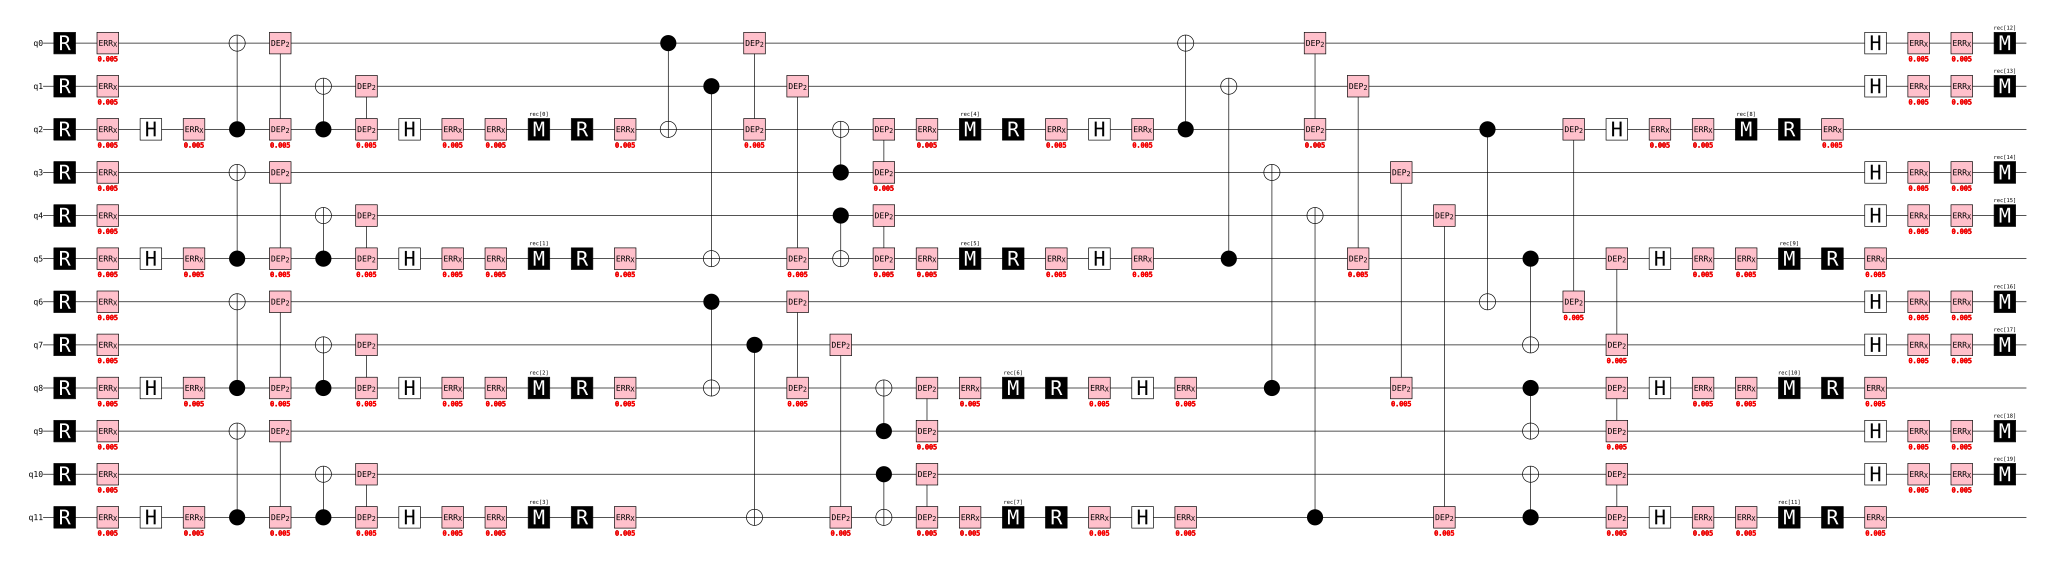

In [160]:
from wrappers.stim_wrapper import (create_circuit_polar_stim_normal, convert_i_to_meas_type, 
simulate_batch_and_save_result_polar_normal)

from wrappers.polar_wrapper import is_q1prep_accepted, get_logical_error_on_accepted_states

i, n, lstate, sim_type, p_error, seed, shots = 4, 3, "x", "normal", 0.005, 12345, 10000
t1, t2, error_1q, readout_error, error_2q = None, None, None, None, None
cm = None

meas_type = convert_i_to_meas_type(i, n, lstate)
N = 2**n
ancilla_qubits = 2**(n - 1)
total_qubits = N + ancilla_qubits
print(meas_type)

x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break

circuit_base = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, 
                           error_1q, readout_error, error_2q,
                           meas_type, total_qubits, x_ind,
                           cm = cm
                            )
circuit_base.diagram("timeline-svg")

In [161]:
circuit_base.to_qasm

<bound method PyCapsule.to_qasm of stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11
    X_ERROR(0.005) 0 1 2 3 4 5 6 7 8 9 10 11
    H 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    CX 2 0 5 3 8 6 11 9
    DEPOLARIZE2(0.005) 2 0 5 3 8 6 11 9
    CX 2 1 5 4 8 7 11 10
    DEPOLARIZE2(0.005) 2 1 5 4 8 7 11 10
    H 2 5 8 11
    X_ERROR(0.005) 2 5 8 11 2 5 8 11
    M 2 5 8 11
    R 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    CX 0 2 1 5 6 8 7 11
    DEPOLARIZE2(0.005) 0 2 1 5 6 8 7 11
    CX 3 2 4 5 9 8 10 11
    DEPOLARIZE2(0.005) 3 2 4 5 9 8 10 11
    X_ERROR(0.005) 2 5 8 11
    M 2 5 8 11
    R 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    H 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    CX 2 0 5 1 8 3 11 4
    DEPOLARIZE2(0.005) 2 0 5 1 8 3 11 4
    CX 2 6 5 7 8 9 11 10
    DEPOLARIZE2(0.005) 2 6 5 7 8 9 11 10
    H 2 5 8 11
    X_ERROR(0.005) 2 5 8 11 2 5 8 11
    M 2 5 8 11
    R 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    H 0 1 3 4 6 7 9 10
    X_ERROR(0.005) 0 1 3 4 6 7 9 10 0 1 3 4 6 7 9 10
    M 0 1 3 4

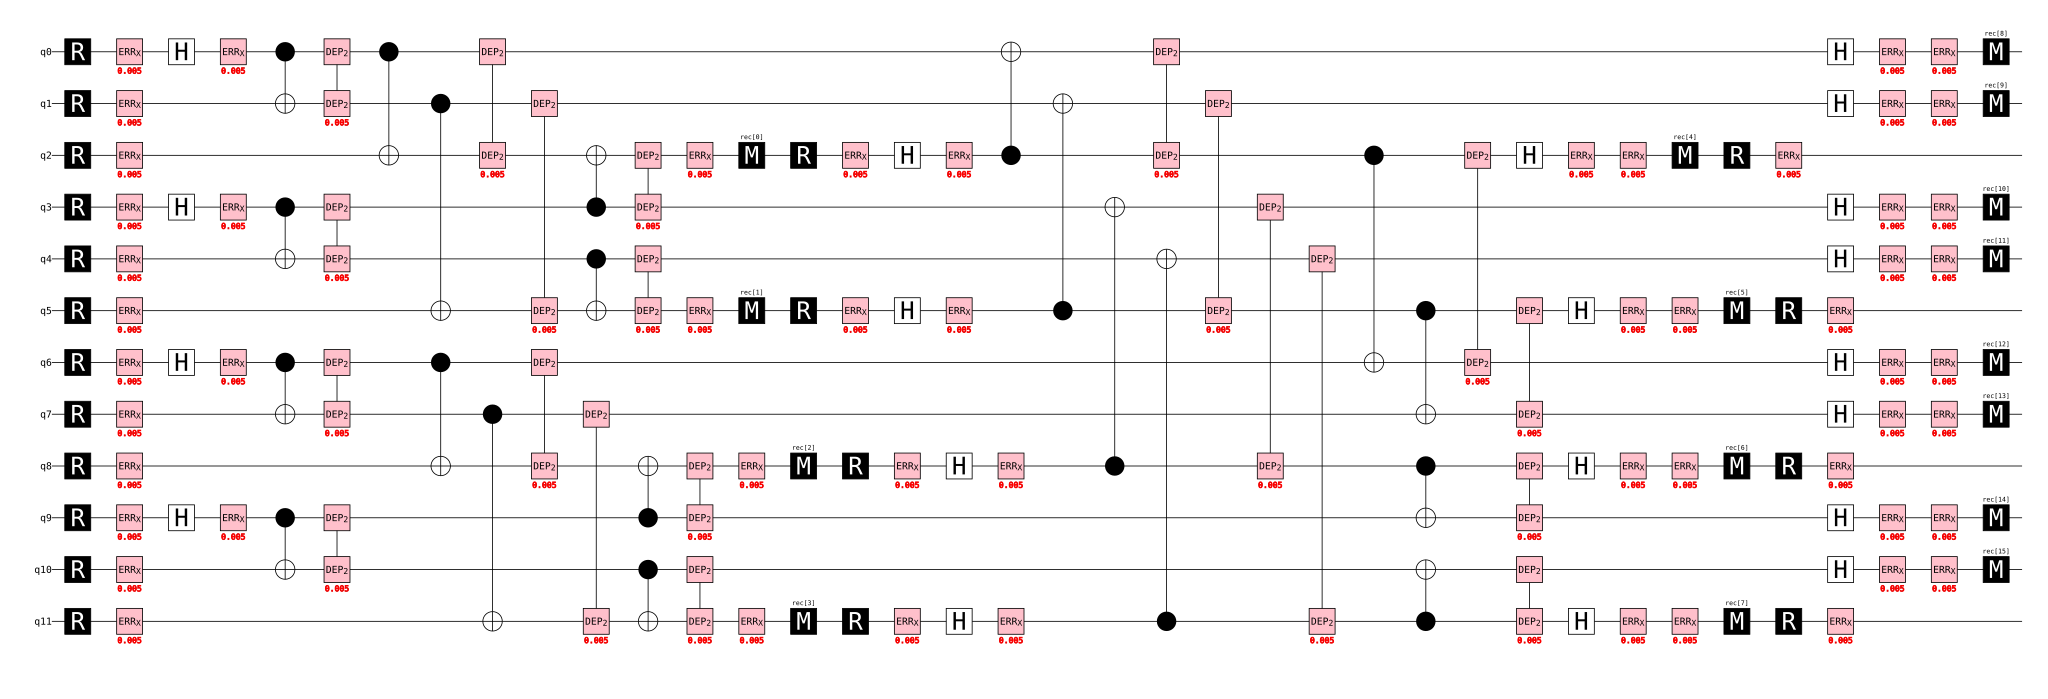

In [162]:
from wrappers.stim_wrapper import create_circuit_polar_stim_normal, convert_i_to_meas_type

sim_type = "m1"

circuit_prop1 = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, 
                           error_1q, readout_error, error_2q,
                           meas_type, total_qubits, x_ind,
                           cm = cm
                            )
circuit_prop1.diagram("timeline-svg")

In [163]:
circuit_prop1.to_qasm

<bound method PyCapsule.to_qasm of stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11
    X_ERROR(0.005) 0 1 2 3 4 5 6 7 8 9 10 11
    H 0 3 6 9
    X_ERROR(0.005) 0 3 6 9
    CX 0 1 3 4 6 7 9 10
    DEPOLARIZE2(0.005) 0 1 3 4 6 7 9 10
    CX 0 2 1 5 6 8 7 11
    DEPOLARIZE2(0.005) 0 2 1 5 6 8 7 11
    CX 3 2 4 5 9 8 10 11
    DEPOLARIZE2(0.005) 3 2 4 5 9 8 10 11
    X_ERROR(0.005) 2 5 8 11
    M 2 5 8 11
    R 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    H 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    CX 2 0 5 1 8 3 11 4
    DEPOLARIZE2(0.005) 2 0 5 1 8 3 11 4
    CX 2 6 5 7 8 9 11 10
    DEPOLARIZE2(0.005) 2 6 5 7 8 9 11 10
    H 2 5 8 11
    X_ERROR(0.005) 2 5 8 11 2 5 8 11
    M 2 5 8 11
    R 2 5 8 11
    X_ERROR(0.005) 2 5 8 11
    H 0 1 3 4 6 7 9 10
    X_ERROR(0.005) 0 1 3 4 6 7 9 10 0 1 3 4 6 7 9 10
    M 0 1 3 4 6 7 9 10
''')>

#### NN Training

In [164]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. DATA EXTRACTION FROM YOUR STIM CIRCUIT
# ==========================================
def extract_polar_dataset(circuit, num_shots=50000, seed=12345):
    set_global_seeds(seed)
    
    # Pass seed directly to FlipSimulator
    sim = stim.FlipSimulator(batch_size=num_shots, seed=seed)
    sim.do(circuit)
    
    # Extract Syndrome X (First 12 measurements)
    raw_measurements = sim.get_measurement_flips()
    X = np.array(raw_measurements, dtype=np.float32)
    if len(X.shape) == 2 and X.shape[0] != num_shots:
        X = X.T
    
    # We only slice the first 12 syndrome bits (ignore final 8 data measurements)
    X_syndrome = X[:, :12]
    
    # Extract Ground Truth Y for Information Qubit 3 (Index 3)
    final_paulis = sim.peek_pauli_flips()
    Y_list = []
    for shot in range(num_shots):
        xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
        # Check if Qubit 3 has an X or Z error
        q3_x = float(xs[3])
        q3_z = float(zs[3])
        Y_list.append([q3_x, q3_z])
        
    Y = np.array(Y_list, dtype=np.float32)
    
    # --- SYNDROME FILTERING ---
    # Filter out clean states (where syndrome sum == 0) to train ONLY on errored data
    errored_mask = (X_syndrome.sum(axis=1) > 0)
    X_filtered = X_syndrome[errored_mask]
    Y_filtered = Y[errored_mask]
    
    print(f"Total Shots Generated : {num_shots}")
    print(f"Clean Shots (X == 0)  : {num_shots - len(X_filtered)}")
    print(f"Errored Shots (X > 0) : {len(X_filtered)} (Used for Training)")
    
    return torch.tensor(X_filtered), torch.tensor(Y_filtered), torch.tensor(X_syndrome), torch.tensor(Y)


##### Training for Baseline

In [165]:
# ==========================================
# 2. NEURAL NETWORK FOR LOGICAL Q3 RECOVERY
# ==========================================
class PolarLogicalDecoder(nn.Module):
    def __init__(self, input_size=12, output_size=2):
        super(PolarLogicalDecoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, output_size) # Outputs: [Q3_X_flip, Q3_Z_flip]
        )

    def forward(self, x):
        return self.net(x)

In [166]:
# ==========================================
# 3. RUNNING THE EXPERIMENT
# ==========================================
# Pass your generated circuit_base here
X_train, Y_train, _, _ = extract_polar_dataset(circuit_base, num_shots=100000)
X_test_filt, Y_test_filt, X_test_all, Y_test_all = extract_polar_dataset(circuit_base, num_shots=20000)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=256, shuffle=True)

model = PolarLogicalDecoder(input_size=12, output_size=2)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 12
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Training Loss: {total_loss/len(train_loader):.4f}")

# ==========================================
# 4. EVALUATING THE CASCADED PIPELINE
# ==========================================
model.eval()
with torch.no_grad():
    # Evaluate Cascaded Decoding on all test shots
    final_preds = torch.zeros_like(Y_test_all)
    
    errored_mask = (X_test_all.sum(dim=1) > 0)
    errored_inputs = X_test_all[errored_mask]
    
    if len(errored_inputs) > 0:
        logits = model(errored_inputs)
        probs = torch.sigmoid(logits)
        final_preds[errored_mask] = (probs > 0.5).float()
        
    # Calculate Logical Error Rate on Q3
    q3_perfect_recovery = (final_preds == Y_test_all).all(dim=1).float().mean().item()
    q3_unfixed_errors = 1.0 - q3_perfect_recovery

    print("\n" + "="*50)
    print("      POLAR CODE Q3 STATE PREPARATION RESULTS    ")
    print("="*50)
    print(f"Total Test Shots             : {len(Y_test_all)}")
    print(f"Q3 Perfect Logical Fidelity  : {q3_perfect_recovery * 100:.2f}%")
    print(f"Residual Q3 Logical Error    : {q3_unfixed_errors * 100:.2f}%")
    print("="*50)

Total Shots Generated : 100000
Clean Shots (X == 0)  : 144
Errored Shots (X > 0) : 99856 (Used for Training)
Total Shots Generated : 20000
Clean Shots (X == 0)  : 28
Errored Shots (X > 0) : 19972 (Used for Training)
Epoch 01/12 | Training Loss: 0.6955
Epoch 02/12 | Training Loss: 0.6937
Epoch 03/12 | Training Loss: 0.6932
Epoch 04/12 | Training Loss: 0.6931
Epoch 05/12 | Training Loss: 0.6931
Epoch 06/12 | Training Loss: 0.6930
Epoch 07/12 | Training Loss: 0.6930
Epoch 08/12 | Training Loss: 0.6929
Epoch 09/12 | Training Loss: 0.6928
Epoch 10/12 | Training Loss: 0.6928
Epoch 11/12 | Training Loss: 0.6926
Epoch 12/12 | Training Loss: 0.6926

      POLAR CODE Q3 STATE PREPARATION RESULTS    
Total Test Shots             : 20000
Q3 Perfect Logical Fidelity  : 25.69%
Residual Q3 Logical Error    : 74.31%


##### Training for the Prop-1

In [ ]:
import stim
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. EXTRACT 8-BIT SYNDROME DATASET
# ==========================================
def extract_8bit_polar_dataset(circuit, num_shots=60000, seed=12345):
    set_global_seeds(seed)
        
    # Pass seed directly to FlipSimulator
    sim = stim.FlipSimulator(batch_size=num_shots, seed=seed)
    sim.do(circuit)
    
    # Extract raw measurement flips
    raw_measurements = sim.get_measurement_flips()
    X = np.array(raw_measurements, dtype=np.float32)
    if len(X.shape) == 2 and X.shape[0] != num_shots:
        X = X.T
    
    # Slice ONLY the first 8 syndrome bits (4 ZZ + 4 XX)
    X_syndrome = X[:, :8]
    
    # Extract Ground Truth Y for Information Qubit 3 (Index 3)
    final_paulis = sim.peek_pauli_flips()
    Y_list = []
    for shot in range(num_shots):
        xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
        # Check X and Z error status on Q3
        q3_x = float(xs[3])
        q3_z = float(zs[3])
        Y_list.append([q3_x, q3_z])
        
    Y = np.array(Y_list, dtype=np.float32)
    
    # Filter out clean states (X_syndrome sum == 0) for training
    errored_mask = (X_syndrome.sum(axis=1) > 0)
    X_filtered = X_syndrome[errored_mask]
    Y_filtered = Y[errored_mask]
    
    print(f"Total Shots Generated : {num_shots}")
    print(f"Clean Shots (X == 0)  : {num_shots - len(X_filtered)}")
    print(f"Errored Shots (X > 0) : {len(X_filtered)} (Used for Training)")
    
    return torch.tensor(X_filtered), torch.tensor(Y_filtered), torch.tensor(X_syndrome), torch.tensor(Y)


# ==========================================
# 2. NEURAL NETWORK FOR 8-BIT SYNDROME DECODING
# ==========================================
class Polar8BitDecoder(nn.Module):
    def __init__(self, input_size=8, output_size=2):
        super(Polar8BitDecoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, output_size)  # Outputs: [Q3_X_flip, Q3_Z_flip]
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
# ==========================================
# 3. RUN THE EXPERIMENT
# ==========================================
# Pass your circuit_base object directly
X_train, Y_train, _, _ = extract_8bit_polar_dataset(circuit_prop1, num_shots=100000)
X_test_filt, Y_test_filt, X_test_all, Y_test_all = extract_8bit_polar_dataset(circuit_base, num_shots=20000)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=256, shuffle=True)

model = Polar8BitDecoder(input_size=8, output_size=2)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nTraining 8-Bit Polar Decoder...")
epochs = 12
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Training Loss: {total_loss/len(train_loader):.4f}")


# ==========================================
# 4. EVALUATE CASCADED DECODING PERFORMANCE
# ==========================================
model.eval()
with torch.no_grad():
    final_preds = torch.zeros_like(Y_test_all)
    
    # Fast classical check: flag non-zero 8-bit syndromes
    errored_mask = (X_test_all.sum(dim=1) > 0)
    errored_inputs = X_test_all[errored_mask]
    
    if len(errored_inputs) > 0:
        logits = model(errored_inputs)
        probs = torch.sigmoid(logits)
        final_preds[errored_mask] = (probs > 0.5).float()
        
    q3_perfect_recovery = (final_preds == Y_test_all).all(dim=1).float().mean().item()
    q3_unfixed_errors = 1.0 - q3_perfect_recovery

    print("\n" + "="*50)
    print("      8-BIT PROPOSAL Q3 PREPARATION RESULTS      ")
    print("="*50)
    print(f"Total Test Shots             : {len(Y_test_all)}")
    print(f"Syndrome Dimension           : 8 bits (4 ZZ + 4 XX)")
    print(f"Q3 Perfect Logical Fidelity  : {q3_perfect_recovery * 100:.2f}%")
    print(f"Residual Q3 Logical Error    : {q3_unfixed_errors * 100:.2f}%")
    print("="*50)

NameError: name 'circuit_prop1' is not defined

### Updated Approach

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import stim

# ==========================================
# 1. NOISELESS REFERENCE EXTRACTION
# ==========================================
def get_noiseless_reference(circuit, seed=12345):
    """
    Simulates the circuit at zero noise to find baseline measurement outcomes.
    """
    # Create zero-noise version of the circuit structure
    sampler = circuit.compile_sampler(seed=seed)
    samples = sampler.sample(shots=1)
    # First 8 measurement bits
    m_ref = samples[0, :8].astype(np.float32)
    return m_ref

# ==========================================
# 2. DATASET GENERATION WITH POLAR FEATURES
# ==========================================
def generate_polar_ml_dataset(circuit, num_shots=80000, seed=12345):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Get baseline reference
    m_ref = get_noiseless_reference(circuit, seed)
    
    # Sample noisy measurements
    sampler = circuit.compile_sampler(seed=seed)
    raw_measurements = sampler.sample(shots=num_shots).astype(np.float32)
    raw_8bit = raw_measurements[:, :8]
    
    # Compute True Syndrome: S = M_noisy XOR M_ref
    syndrome = np.bitwise_xor(raw_8bit.astype(int), m_ref.astype(int)).astype(np.float32)
    
    # Extract Ground Truth Y for Information Qubit 3 (Index 3)
    sim = stim.FlipSimulator(batch_size=num_shots, seed=seed)
    sim.do(circuit)
    final_paulis = sim.peek_pauli_flips()
    
    Y_list = []
    for shot in range(num_shots):
        xs, zs = final_paulis[shot].to_numpy(bit_packed=False)
        Y_list.append([float(xs[3]), float(zs[3])])
    Y = np.array(Y_list, dtype=np.float32)
    
    # --- FEATURE ENGINEERING (8 Base Syndromes + 28 Pairwise XOR Features = 36 Inputs) ---
    interaction_features = []
    for i in range(8):
        for j in range(i + 1, 8):
            # Pairwise XOR parity check
            xor_ij = np.bitwise_xor(syndrome[:, i].astype(int), syndrome[:, j].astype(int))
            interaction_features.append(xor_ij)
            
    interaction_matrix = np.column_stack(interaction_features).astype(np.float32)
    X_expanded = np.hstack([syndrome, interaction_matrix])
    
    # Filter ONLY shots where a physical syndrome was detected (sum > 0)
    has_syndrome = (syndrome.sum(axis=1) > 0)
    X_filtered = X_expanded[has_syndrome]
    Y_filtered = Y[has_syndrome]
    
    print(f"Total Shots Generated : {num_shots}")
    print(f"Errored Shots Filtered: {len(X_filtered)} (Used for NN Training)")
    return torch.tensor(X_filtered), torch.tensor(Y_filtered)


# ==========================================
# 3. ADVANCED POLAR DECODER ARCHITECTURE
# ==========================================
class PolarFeatureDecoder(nn.Module):
    def __init__(self, input_size=36, output_size=2):
        super(PolarFeatureDecoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(256),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        return self.net(x)


# ==========================================
# 4. TRAINING WITH POSITIVE CLASS WEIGHTING
# ==========================================
# Generate Train / Test Data
X_train, Y_train = generate_polar_ml_dataset(circuit_base, num_shots=100000, seed=12345)
X_test, Y_test = generate_polar_ml_dataset(circuit_base, num_shots=20000, seed=54321)

# Compute pos_weight to balance zero vs. one flips on Q3
pos_counts = Y_train.sum(dim=0)
total_samples = len(Y_train)
pos_weights = (total_samples - pos_counts) / torch.clamp(pos_counts, min=1.0)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=256, shuffle=True)

model = PolarFeatureDecoder(input_size=36, output_size=2)
# Weighted BCE Loss handles low-rate target flips
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

print("\nTraining Polar Feature Decoder...")
epochs = 15
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Training Loss: {avg_loss:.4f}")

# ==========================================
# 5. CASCADED EVALUATION
# ==========================================
model.eval()
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).float()
    
    exact_q3_recovery = (predictions == Y_test).all(dim=1).float().mean().item()
    bitwise_q3_acc = (predictions == Y_test).float().mean().item()

    print("\n" + "="*50)
    print("      FEATURE-ENHANCED POLAR DECODER RESULTS     ")
    print("="*50)
    print(f"Tested Errored Shots        : {len(Y_test)}")
    print(f"Q3 Perfect Logical Fidelity : {exact_q3_recovery * 100:.2f}%")
    print(f"Q3 Bitwise Accuracy         : {bitwise_q3_acc * 100:.2f}%")
    print("="*50)

Total Shots Generated : 100000
Errored Shots Filtered: 99914 (Used for NN Training)
Total Shots Generated : 20000
Errored Shots Filtered: 19721 (Used for NN Training)

Training Polar Feature Decoder...
Epoch 01/15 | Training Loss: 0.7007
Epoch 02/15 | Training Loss: 0.6958
Epoch 03/15 | Training Loss: 0.6952
Epoch 04/15 | Training Loss: 0.6949
Epoch 05/15 | Training Loss: 0.6948
Epoch 06/15 | Training Loss: 0.6947
Epoch 07/15 | Training Loss: 0.6947
Epoch 08/15 | Training Loss: 0.6946
Epoch 09/15 | Training Loss: 0.6946
Epoch 10/15 | Training Loss: 0.6945
Epoch 11/15 | Training Loss: 0.6944
Epoch 12/15 | Training Loss: 0.6943
Epoch 13/15 | Training Loss: 0.6943
Epoch 14/15 | Training Loss: 0.6943
Epoch 15/15 | Training Loss: 0.6943

      FEATURE-ENHANCED POLAR DECODER RESULTS     
Tested Errored Shots        : 19721
Q3 Perfect Logical Fidelity : 24.91%
Q3 Bitwise Accuracy         : 49.91%


In [ ]:
result = simulate_batch_and_save_result_polar_normal(n, lstate, sim_type, p_error, i, shots, seed, "val")
result

{'n': 3,
 'lstate': 'x',
 'i': 4,
 'meas_type': ['x', 'z', 'x'],
 'p_error': 0.005,
 'sim_type': 'normal',
 'decoder_type': 'val',
 'total_meta_shots': 0,
 'shots': 10000,
 'count_accept': 7629,
 'count_logerror': 394,
 'count_undecided': 751,
 'count_detect_discard': 0,
 'prep_rate': 0.7629,
 'LER': 0.05164503866823966,
 'detect_normal': 0,
 'decoding_normal': 0.5669171761255711}

### QED

In [167]:
import numpy as np
import torch

def generate_filtered_qed_dataset(circuit, is_accepted_func, num_shots=100000, seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # 1. Sample Noisy Data from Hardware / Stim
    sampler_noisy = circuit.compile_sampler(seed=seed)
    raw_measurements = sampler_noisy.sample(shots=num_shots)
    
    # 2. Separate State Prep Syndromes (First 12) & Steane Data Measurements (Last 8)
    syndromes = raw_measurements[:, :12]
    syndromes_int = syndromes.astype(int)

    data_measurements = raw_measurements[:, 12:]
    
    # 3. Ground Truth: Target error status of Information Qubit Q3 (Index 3)
    info_idx = 3 
    y_target = data_measurements[:, info_idx].reshape(-1, 1).astype(np.float32)
    
    # 4. Filter using your custom Classical Acceptance Function
    # Checks each syndrome vector against your classical error detection rules
    accepted_mask = np.array([is_accepted_func(3, 2, s[::-1]) for s in syndromes_int], dtype=bool)
    rejected_mask = ~accepted_mask
    
    # Extract ONLY rejected shots for training the NN
    X_rejected = syndromes[rejected_mask].astype(np.float32)
    Y_rejected = y_target[rejected_mask]
    
    # Performance Baseline Metrics
    total_accepted = accepted_mask.sum()
    total_rejected = rejected_mask.sum()
    
    print("="*55)
    print("        DATASET GENERATION WITH CLASSICAL FILTERING       ")
    print("="*55)
    print(f"Total Shots Simulated     : {num_shots}")
    print(f"Classically Accepted      : {total_accepted} ({100 * total_accepted / num_shots:.2f}% Yield)")
    print(f"Classically Rejected      : {total_rejected} ({100 * total_rejected / num_shots:.2f}% Sent to NN)")
    print("="*55)
    
    return (
        torch.tensor(X_rejected), 
        torch.tensor(Y_rejected), 
        torch.tensor(syndromes, dtype=torch.float32), 
        torch.tensor(y_target),
        torch.tensor(raw_measurements, dtype=torch.float32)
    )

In [168]:
result = generate_filtered_qed_dataset(circuit_base, is_q1prep_accepted, num_shots=10000, seed=101)
# result 

        DATASET GENERATION WITH CLASSICAL FILTERING       
Total Shots Simulated     : 10000
Classically Accepted      : 7580 (75.80% Yield)
Classically Rejected      : 2420 (24.20% Sent to NN)


['x', 'z', 'x']


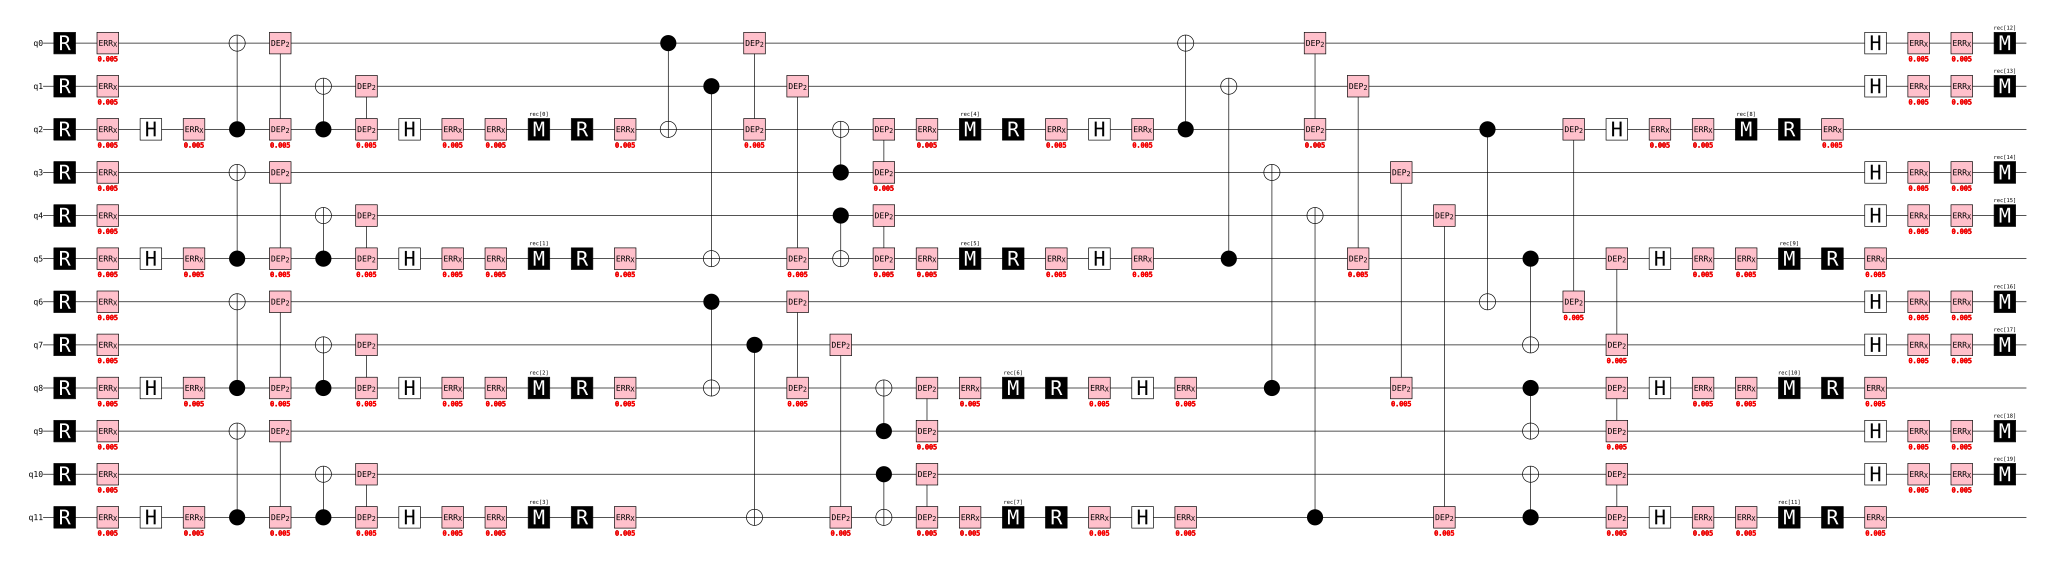

In [169]:
from wrappers.stim_wrapper import (create_circuit_polar_stim_normal, convert_i_to_meas_type, 
simulate_batch_and_save_result_polar_normal)

from wrappers.polar_wrapper import is_q1prep_accepted

i, n, lstate, sim_type, p_error, seed, shots = 4, 3, "x", "normal", 0.005, 12345, 10000
t1, t2, error_1q, readout_error, error_2q = None, None, None, None, None
cm = None

meas_type = convert_i_to_meas_type(i, n, lstate)
N = 2**n
ancilla_qubits = 2**(n - 1)
total_qubits = N + ancilla_qubits
print(meas_type)

x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break

circuit_base = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, 
                           error_1q, readout_error, error_2q,
                           meas_type, total_qubits, x_ind,
                           cm = cm
                            )
circuit_base.diagram("timeline-svg")

In [170]:
sampler_noisy = circuit_base.compile_sampler(seed=1234)
raw_measurements = sampler_noisy.sample(shots=10000)
syndromes = raw_measurements[:, :12]

syndromes_int = syndromes.astype(int)

syndromes_str = []

for res in syndromes:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    syndromes_str.append(bit_string)

n = 3
N = 8
count_accept = 0
count_discard = 0

# counts = {}
# for res in syndromes:
#     bit_string = ""
#     for j in res:
#         if j:
#             bit_string = "1" + bit_string 
#         else:
#             bit_string = "0" + bit_string

#     if sim_type in ["m1", "m2", "m3"]:
#         bit_string = bit_string + "0"*(2**(n - 1))

#     if bit_string in counts:
#         counts[bit_string] = counts[bit_string] + 1
#     else:
#         counts[bit_string] = 1 

# print(counts)

zpos_list = None
if zpos_list == None:
    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]

    if lstate == "z":
        # |0> is prepared: take zpos value from the list above
        zpos = zpos_list[n]
    elif lstate == "x":
        # |+> is prepared: zpos value from the list above -1
        zpos = zpos_list[n] -1
    else:
        raise TypeError("Illegal 'lstate' value")

for line in syndromes_int:
    # # check if 'meas' are valid measurement results
    success = is_q1prep_accepted(3, zpos, line[::-1])
    if success == 1:
        count_accept = count_accept + 1
        # print(meas)
    else:
        count_discard = count_discard + 1

print(count_accept, count_discard, zpos)

7634 2366 2


In [171]:
syndromes[0]

array([ True,  True, False, False, False, False, False,  True,  True,
       False, False,  True])

In [172]:
result = generate_filtered_qed_dataset(circuit_base, is_q1prep_accepted, num_shots=10000, seed=101)
# result

        DATASET GENERATION WITH CLASSICAL FILTERING       
Total Shots Simulated     : 10000
Classically Accepted      : 7580 (75.80% Yield)
Classically Rejected      : 2420 (24.20% Sent to NN)


In [173]:
class SmartQEDFilter(nn.Module):
    def __init__(self):
        super(SmartQEDFilter, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(12, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [174]:
# def evaluate_cascaded_qed(model, X_test_all, Y_test_all, is_accepted_func):
#     model.eval()
#     with torch.no_grad():
#         num_shots = len(X_test_all)
        
#         # Step 1: Classical Acceptance Check
#         classical_mask = np.array([is_accepted_func(3, 2, s.numpy()) for s in X_test_all], dtype=bool)
#         classical_yield = classical_mask.mean()
        
#         # Step 2: NN re-evaluates ONLY rejected shots
#         rejected_mask = ~classical_mask
#         X_rejected = X_test_all[rejected_mask]
        
#         nn_rescued_mask = torch.zeros(num_shots, dtype=torch.bool)
#         if len(X_rejected) > 0:
#             logits = model(X_rejected)
#             probs = torch.sigmoid(logits)
#             # If NN predicts low error probability (< 0.5), it rescues the rejected state
#             rescued_indices = (probs < 0.5).squeeze().cpu().numpy()
            
#             # Map rescued shots back to global array
#             rejected_indices = np.where(rejected_mask)[0]
#             rescued_global_indices = rejected_indices[rescued_indices]
#             nn_rescued_mask[rescued_global_indices] = True

#         # Final Combined Acceptance (Classical Accepted + NN Rescued)
#         total_accepted_mask = torch.tensor(classical_mask) | nn_rescued_mask
#         final_yield = total_accepted_mask.float().mean().item()
        
#         # Fidelity Metrics (Checking if Q3 actually had NO error among accepted states)
#         classical_fidelity = 1.0 - Y_test_all[classical_mask].mean().item() if classical_mask.sum() > 0 else 1.0
#         final_fidelity = 1.0 - Y_test_all[total_accepted_mask].mean().item() if total_accepted_mask.sum() > 0 else 1.0

#         print("\n" + "="*55)
#         print("          CASCADED QED CONTROLLER EVALUATION          ")
#         print("="*55)
#         print(f"Classical QED Only   | Yield: {classical_yield*100:05.2f}% | Fidelity: {classical_fidelity*100:.2f}%")
#         print(f"NN-Enhanced Cascaded | Yield: {final_yield*100:05.2f}% | Fidelity: {final_fidelity*100:.2f}%")
#         print(f"Absolute Yield Boost : +{(final_yield - classical_yield)*100:.2f}% additional valid states saved")
#         print("="*55)

#         # Return the matrices for your SC Decoder
#         return accepted_syndromes, accepted_data_bits

In [175]:
def evaluate_cascaded_qed(model, X_test_all, Y_test_all, Data_test_all, is_accepted_func):
    model.eval()
    with torch.no_grad():
        num_shots = len(X_test_all)
        
        # Step 1: Classical Acceptance
        classical_mask = np.array([is_accepted_func(3, 2, s.numpy()) for s in X_test_all], dtype=bool)
        
        # Step 2: NN Rescues from Rejected Pool
        rejected_mask = ~classical_mask
        X_rejected = X_test_all[rejected_mask]
        
        nn_rescued_mask = torch.zeros(num_shots, dtype=torch.bool)
        if len(X_rejected) > 0:
            logits = model(X_rejected)
            probs = torch.sigmoid(logits)
            
            # Keep states where NN predicts error probability < 0.5
            rescued_indices = (probs < 0.5).squeeze().cpu().numpy()
            rejected_indices = np.where(rejected_mask)[0]
            rescued_global_indices = rejected_indices[rescued_indices]
            nn_rescued_mask[rescued_global_indices] = True

        # Combine both masks
        total_accepted_mask = torch.tensor(classical_mask) | nn_rescued_mask
        
        # --- NEW: EXTRACT THE ACCEPTED STATES ---
        accepted_syndromes = X_test_all[total_accepted_mask]
        accepted_data_bits = Data_test_all[total_accepted_mask]
        
        # Calculate Metrics
        final_yield = total_accepted_mask.float().mean().item()
        final_fidelity = 1.0 - Y_test_all[total_accepted_mask].mean().item() if total_accepted_mask.sum() > 0 else 1.0

        print(f"Final Yield: {final_yield*100:.2f}% | Final Fidelity: {final_fidelity*100:.2f}%")
        
        # Return the matrices for your SC Decoder
        return accepted_syndromes, accepted_data_bits

In [176]:
# ==========================================
# 6. MAIN EXPERIMENT LOOP
# ==========================================
if __name__ == "__main__":
    print("="*55)
    print("        PREPARING DATASETS       ")
    print("="*55)
    # Generate Training Data (we only use X_train_rejected and Y_train_rejected)
    X_train_rej, Y_train_rej, _, _, _ = generate_filtered_qed_dataset(
        circuit_base, is_q1prep_accepted, num_shots=100000, seed=101
    )
    
    # Generate Testing Data (we keep the ALL sets for evaluation)
    _, _, X_test_all, Y_test_all, Data_test_all = generate_filtered_qed_dataset(
        circuit_base, is_q1prep_accepted, num_shots=100000, seed=202
    )

    train_loader = DataLoader(TensorDataset(X_train_rej, Y_train_rej), batch_size=256, shuffle=True)

    model = SmartQEDFilter()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    
    # Handle severe class imbalance in the rejected set
    num_positives = Y_train_rej.sum()
    num_negatives = len(Y_train_rej) - num_positives
    pos_weight = num_negatives / torch.clamp(num_positives, min=1.0)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print("\n" + "="*55)
    print("        TRAINING NEURAL NETWORK       ")
    print("="*55)
    epochs = 300
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Loss: {total_loss/len(train_loader):.4f}")

    

        PREPARING DATASETS       
        DATASET GENERATION WITH CLASSICAL FILTERING       
Total Shots Simulated     : 100000
Classically Accepted      : 76504 (76.50% Yield)
Classically Rejected      : 23496 (23.50% Sent to NN)
        DATASET GENERATION WITH CLASSICAL FILTERING       
Total Shots Simulated     : 100000
Classically Accepted      : 76249 (76.25% Yield)
Classically Rejected      : 23751 (23.75% Sent to NN)

        TRAINING NEURAL NETWORK       
Epoch 01/300 | Loss: 0.7029
Epoch 02/300 | Loss: 0.6949
Epoch 03/300 | Loss: 0.6937
Epoch 04/300 | Loss: 0.6925
Epoch 05/300 | Loss: 0.6930
Epoch 06/300 | Loss: 0.6916
Epoch 07/300 | Loss: 0.6919
Epoch 08/300 | Loss: 0.6916
Epoch 09/300 | Loss: 0.6916
Epoch 10/300 | Loss: 0.6916
Epoch 11/300 | Loss: 0.6913
Epoch 12/300 | Loss: 0.6913
Epoch 13/300 | Loss: 0.6911
Epoch 14/300 | Loss: 0.6906
Epoch 15/300 | Loss: 0.6906
Epoch 16/300 | Loss: 0.6902
Epoch 17/300 | Loss: 0.6901
Epoch 18/300 | Loss: 0.6897
Epoch 19/300 | Loss: 0.6896


In [193]:
# Run the final evaluation
# evaluate_cascaded_qed(model, X_test_all, Y_test_all, is_q1prep_accepted)
final_syndromes, final_data_bits = evaluate_cascaded_qed(
    model, X_test_all, Y_test_all, Data_test_all, is_q1prep_accepted
)

Final Yield: 87.99% | Final Fidelity: 49.81%


In [189]:
len(final_data_bits)

87992

In [181]:
counts = {}
for res in final_data_bits:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if sim_type in ["m1", "m2", "m3"]:
        bit_string = bit_string + "0"*(2**(n - 1))

    if bit_string in counts:
        counts[bit_string] = counts[bit_string] + 1
    else:
        counts[bit_string] = 1  

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = \
            get_logical_error_on_accepted_states(
                n, lstate.upper(), counts, zpos_list
            )

print(count_accept, count_accept/len(final_data_bits), count_logerror, count_undecided, 1-ler, detect_normal, decoding_normal)

76249 0.8665446858805346 3709 7050 0.04864326089522486 0 2.095967255998403


In [190]:
len(Data_test_all)

100000

In [192]:
counts = {}
for res in Data_test_all:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if sim_type in ["m1", "m2", "m3"]:
        bit_string = bit_string + "0"*(2**(n - 1))

    if bit_string in counts:
        counts[bit_string] = counts[bit_string] + 1
    else:
        counts[bit_string] = 1  

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = \
            get_logical_error_on_accepted_states(
                n, lstate.upper(), counts, zpos_list
            )

print(count_accept, count_accept/len(Data_test_all), count_logerror, count_undecided, 1-ler, detect_normal, decoding_normal)

76249 0.76249 3709 7050 0.04864326089522486 0 1.9540559900924563


### Pauli Frame Tracking

In [ ]:
import stim
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. GENERATE THE DATASET (PAULI FRAME TRACKING)
# ==========================================
def extract_pauli_frame_dataset(circuit, info_qubit=3, num_shots=100000, seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # 1. Parse the circuit and append a final measurement on the Information Qubit
    # This acts as our Ground Truth (The actual logical frame of the qubit)
    circuit.append("M", [info_qubit]) 
    
    # 2. Sample the circuit using a standard sampler (Not FlipSimulator)
    # This gives us the actual 0s and 1s produced by the hardware
    sampler = circuit.compile_sampler(seed=seed)
    samples = sampler.sample(shots=num_shots)
    
    # 3. Split the data
    # X: The first 8 bits (Ancilla parity checks)
    # Y: The last bit (The final state of Qubit 3)
    X = samples[:, :8].astype(np.float32)
    Y = samples[:, -1].astype(np.float32).reshape(-1, 1)
    
    return torch.tensor(X), torch.tensor(Y)


# ==========================================
# 2. THE NEURAL NETWORK MODEL
# ==========================================
class PauliFrameDecoder(nn.Module):
    def __init__(self):
        super(PauliFrameDecoder, self).__init__()
        # A lightweight network is often enough to learn the Polar decoding graph
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Outputs a single bit prediction for Q3
        )

    def forward(self, x):
        return self.net(x)


# ==========================================
# 3. EXPERIMENT EXECUTION
# ==========================================


# Generate 100k shots for training, 20k for testing
X_train, Y_train = extract_pauli_frame_dataset(circuit_prop1, info_qubit=3, num_shots=100000, seed=101)
X_test, Y_test = extract_pauli_frame_dataset(circuit_prop1, info_qubit=3, num_shots=20000, seed=202)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=256, shuffle=True)

model = PauliFrameDecoder()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

print("Training Pauli Frame Network...")
epochs = 15
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Loss: {total_loss/len(train_loader):.4f}")

# ==========================================
# 4. EVALUATION
# ==========================================
model.eval()
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).float()
    
    correct_predictions = (predictions == Y_test).float().sum().item()
    total_samples = len(Y_test)
    accuracy = (correct_predictions / total_samples) * 100
    
    print("\n" + "="*50)
    print("      PAULI FRAME TRACKING RESULTS      ")
    print("="*50)
    print(f"Total Test Shots Kept       : {total_samples} (100% Yield)")
    print(f"Q3 Final State Accuracy     : {accuracy:.2f}%")
    print(f"Logical Error Rate (LER)    : {100.0 - accuracy:.2f}%")
    print("="*50)

Training Pauli Frame Network...
Epoch 01/15 | Loss: 0.6934
Epoch 02/15 | Loss: 0.6932
Epoch 03/15 | Loss: 0.6932
Epoch 04/15 | Loss: 0.6932
Epoch 05/15 | Loss: 0.6932
Epoch 06/15 | Loss: 0.6932
Epoch 07/15 | Loss: 0.6932
Epoch 08/15 | Loss: 0.6933
Epoch 09/15 | Loss: 0.6932
Epoch 10/15 | Loss: 0.6932
Epoch 11/15 | Loss: 0.6932
Epoch 12/15 | Loss: 0.6932
Epoch 13/15 | Loss: 0.6932
Epoch 14/15 | Loss: 0.6931
Epoch 15/15 | Loss: 0.6932

      PAULI FRAME TRACKING RESULTS      
Total Test Shots Kept       : 20000 (100% Yield)
Q3 Final State Accuracy     : 50.35%
Logical Error Rate (LER)    : 49.65%
